In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv('oto_full_data.csv')
data

def priceStrtoInt(series):
    def convert_one(priceStr):
        if(priceStr == 'nan'):
            return 0
        priceStr = str(priceStr)
        if("tỉ" not in priceStr and "triệu" not in priceStr):
            return 0
        price = 0
        priceStr = str(priceStr).replace(" tỉ","000").replace("triệu","").strip()
        nums = priceStr.split()
        price = sum(float(x) for  x in nums)
        return price
    return series.apply(convert_one)
        
def soKmdadiToInt(series):
    def convert_one(km):
        if km == '' or km == 'nan':
            return 0
        return float(str(km).replace('.','').replace(' km','').strip())
    return series.apply(convert_one)


print(data['Giá'])
print(data['Số km đã đi'])




0            450 triệu
1       1 tỉ 650 triệu
2            325 triệu
3            515 triệu
4            700 triệu
             ...      
2225         495 triệu
2226         305 triệu
2227         605 triệu
2228         399 triệu
2229         750 triệu
Name: Giá, Length: 2230, dtype: object
0        80.000 km
1        26.000 km
2       130.000 km
3        83.000 km
4        43.000 km
           ...    
2225     73.000 km
2226     70.000 km
2227      8.000 km
2228      8.000 km
2229      8.000 km
Name: Số km đã đi, Length: 2230, dtype: object


In [3]:
data['Số km đã đi'] = soKmdadiToInt(data['Số km đã đi'].astype(str))
data['Giá'] = priceStrtoInt(data['Giá'].astype(str))


print(data['Giá'])
print(data['Số km đã đi'])



0        450.0
1       1650.0
2        325.0
3        515.0
4        700.0
         ...  
2225     495.0
2226     305.0
2227     605.0
2228     399.0
2229     750.0
Name: Giá, Length: 2230, dtype: float64
0        80000.0
1        26000.0
2       130000.0
3        83000.0
4        43000.0
          ...   
2225     73000.0
2226     70000.0
2227      8000.0
2228      8000.0
2229      8000.0
Name: Số km đã đi, Length: 2230, dtype: float64


In [4]:
Cols = data.columns
print(data[Cols].isna().sum())

Ngày đăng bài     0
Tên               1
Năm sản xuất      1
Xuất xứ          13
Địa điểm          1
Kiểu dáng        77
Số km đã đi       0
Hộp số            1
Trạng thái        1
Nhiên Liệu        1
Giá               0
dtype: int64


In [5]:
textCols = data.select_dtypes(include='object').columns
for col in textCols:
    data[col].fillna(data[col].mode().iloc[0], inplace=True)
# hàm mode() lấy ra 1 mảng gồm các giá trị xuất hiện nhiều nhất trong cột (nếu số lần = nhau) iloc[0] để móc ra cái đầu tiên thui
# inplace = True để thay thế fill trực tiếp vào data chứ ko cần gán lại
data['Năm sản xuất'].fillna(data['Năm sản xuất'].mode().iloc[0], inplace=True)

#numCols = data.select_dtypes(include='float64').columns
# for col in numCols:
#     data[col].fillna(data[col].mean(),inplace='True')
print(data[Cols].isna().sum())


Ngày đăng bài    0
Tên              0
Năm sản xuất     0
Xuất xứ          0
Địa điểm         0
Kiểu dáng        0
Số km đã đi      0
Hộp số           0
Trạng thái       0
Nhiên Liệu       0
Giá              0
dtype: int64


C:\Users\hoany\AppData\Local\Temp\ipykernel_18140\4132173324.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode().iloc[0], inplace=True)
C:\Users\hoany\AppData\Local\Temp\ipykernel_18140\4132173324.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [6]:
numCols = data.select_dtypes(include='float64').columns
dataNoOutlines = data.copy()
for col in numCols:
    mean = dataNoOutlines[col].mean()
    std = dataNoOutlines[col].std()
    lower = mean - 3*std
    upper = mean + 3*std
    
    outliers = [i for i in dataNoOutlines[col] if i < lower or i > upper]
    print(f"{col}:{lower} {upper} :{outliers}")
    dataNoOutlines = dataNoOutlines[(dataNoOutlines[col]>=lower) & (dataNoOutlines[col]<=upper)]
print(f"Du lieu truoc khi bo ngoai lai{data.shape}")
print(f"Du lieu sau khi bo ngoai lai{dataNoOutlines.shape}")
    
    


Năm sản xuất:2003.3115003031567 2032.8849122528973 :[2003.0, 2003.0, 2002.0, 2001.0, 2003.0, 2003.0, 2002.0, 2003.0, 2002.0, 2003.0, 2002.0]
Số km đã đi:-150319.27285210637 289808.7068313763 :[580000.0, 390000.0, 788000.0, 300000.0, 370000.0, 600000.0, 970000.0, 800000.0, 789789.0, 300718.0, 320000.0, 900000.0, 400000.0, 940000.0, 580000.0, 300000.0, 800000.0]
Giá:-2635.6479674272223 4202.673943812327 :[4290.0, 4450.0, 11900.0, 4999.0, 4299.0, 7900.0, 4550.0, 9850.0, 9390.0, 4399.0, 9900.0, 4680.0, 5890.0, 7999.0, 7799.0, 6399.0, 4668.0, 4269.0, 11900.0, 9650.0, 9290.0, 7449.0, 4880.0, 6558.0, 9390.0, 13000.0, 9600.0, 9850.0, 4299.0, 6390.0, 8550.0, 7150.0, 8650.0, 9650.0, 8650.0, 8150.0, 6500.0, 4800.0, 9650.0, 10999.0, 6200.0, 6380.0]
Du lieu truoc khi bo ngoai lai(2230, 11)
Du lieu sau khi bo ngoai lai(2160, 11)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler() #tạo 1 instance cho công cụ chuẩn hóa

dataNoOutlines[[c+'_scale' for c in numCols]] = minmax_scaler.fit_transform(dataNoOutlines[numCols])
dataNoOutlines

,Ngày đăng bài,Tên,Năm sản xuất,Xuất xứ,Địa điểm,Kiểu dáng,Số km đã đi,Hộp số,Trạng thái,Nhiên Liệu,Giá,Năm sản xuất_scale,Số km đã đi_scale,Giá_scale
0,05/10/2025,Hyundai Kona 2.0 AT Đặc biệt 2019,2019.0,Trong nước,Nam Từ Liêm - Hà Nội,SUV,80000.0,Số tự động,Xe cũ,Máy xăng,450.0,0.714286,0.283712,0.107681
1,15/10/2025,Mercedes-Benz E200 Exclusive 2022,2022.0,Trong nước,Tp.HCM,Sedan,26000.0,Số tự động,Xe cũ,Máy xăng,1650.0,0.857143,0.092206,0.394831
2,24/09/2025,Hyundai Accent 1.4 MT Tiêu chuẩn 2022,2022.0,Trong nước,Tân An - Long An,Sedan,130000.0,Số sàn,Xe cũ,Máy xăng,325.0,0.857143,0.461032,0.077770
3,14/10/2025,Mitsubishi Xpander AT Premium 2022,2022.0,Trong nước,Chí Linh - Hải Dương,SUV,83000.0,Số tự động,Xe cũ,Máy xăng,515.0,0.857143,0.294351,0.123235
4,13/10/2025,Toyota Corolla Cross 1.8 V 2023,2023.0,Trong nước,An Dương - Hải Phòng,SUV,43000.0,Số tự động,Xe cũ,Máy xăng,700.0,0.904762,0.152495,0.167504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225,27/09/2025,Mitsubishi Triton 4×2 AT MIVEC 2020,2020.0,Nhập khẩu,Bắc Từ Liêm - Hà Nội,Bán tải,73000.0,Số tự động,Xe cũ,Máy dầu,495.0,0.761905,0.258887,0.118449
2226,26/09/2025,Hyundai Grand i10 Sedan 1.2 AT 2019,2019.0,Trong nước,Quận 6 - Tp.HCM,Hatchback,70000.0,Số tự động,Xe cũ,Máy xăng,305.0,0.714286,0.248248,0.072984
2227,20/09/2025,Nissan X trail 2.5 SV 4WD 2019,2019.0,Trong nước,Thanh Xuân - Hà Nội,SUV,8000.0,Số tự động,Xe cũ,Máy xăng,605.0,0.714286,0.028371,0.144771
2228,21/09/2025,Mazda CX-5 2.0 Luxury 2012,2012.0,Nhập khẩu,Thanh Xuân - Hà Nội,SUV,8000.0,Số tự động,Xe cũ,Máy xăng,399.0,0.380952,0.028371,0.095477


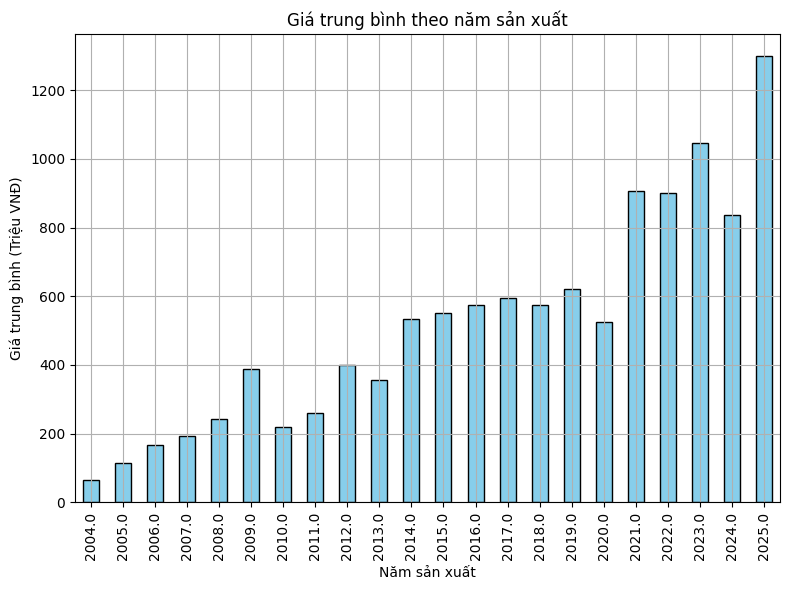

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt


means = dataNoOutlines.groupby('Năm sản xuất')['Giá'].mean()
plt.figure(figsize=(8,6))
means.plot(kind='bar', color='skyblue', edgecolor='black')  # Bar chart
plt.xlabel('Năm sản xuất')
plt.ylabel('Giá trung bình (Triệu VNĐ)')
plt.title('Giá trung bình theo năm sản xuất')
plt.grid(True)  # Lưới để dễ đọc (tùy chọn)
plt.tight_layout()
plt.show()


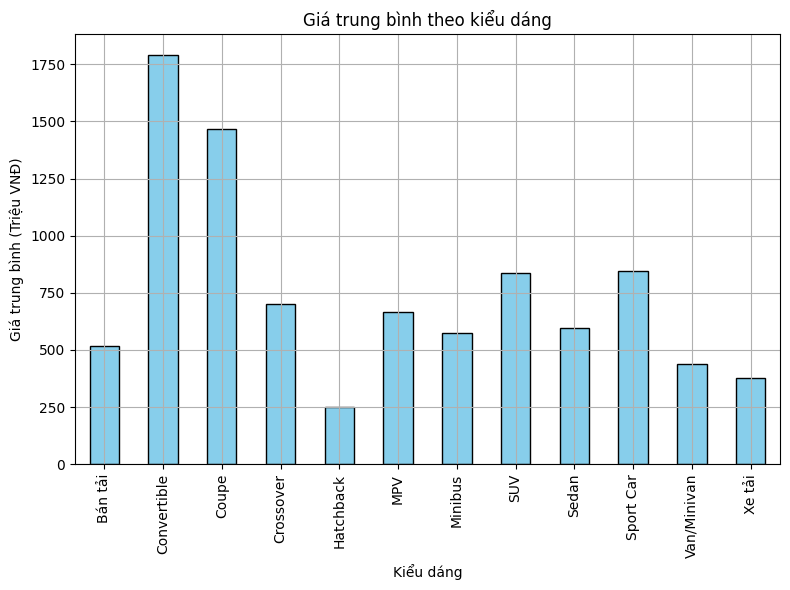

In [27]:
means = dataNoOutlines.groupby('Kiểu dáng')['Giá'].mean()
plt.figure(figsize=(8,6))
means.plot(kind='bar', color='skyblue', edgecolor='black')  # Bar chart
plt.xlabel('Kiểu dáng')
plt.ylabel('Giá trung bình (Triệu VNĐ)')
plt.title('Giá trung bình theo kiểu dáng')
plt.grid(True)  # Lưới để dễ đọc (tùy chọn)
plt.tight_layout()
plt.show()



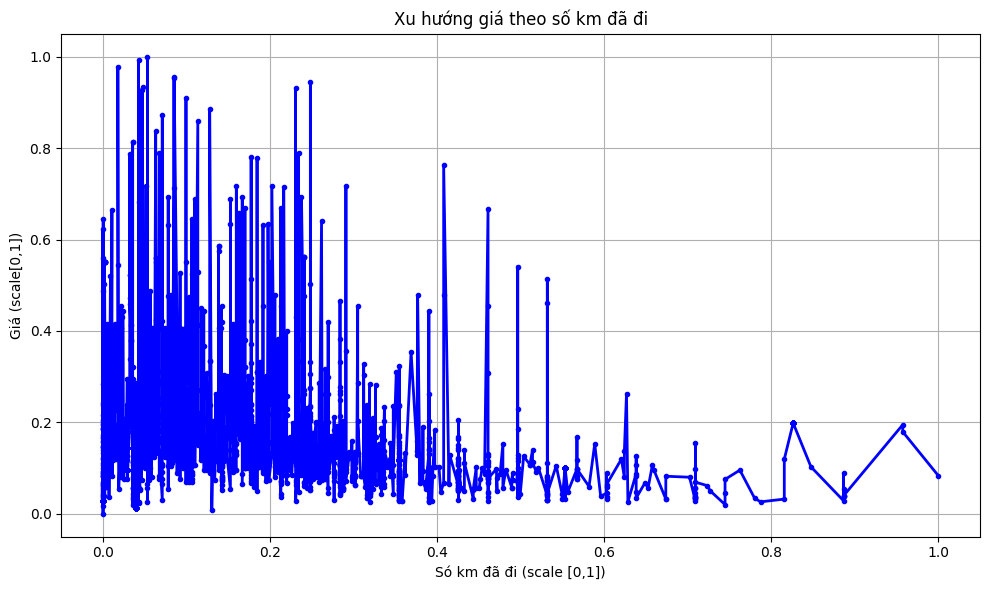

In [ ]:
data_sorted=dataNoOutlines.sort_values('Số km đã đi_scale')

plt.figure(figsize=(10,6))
plt.plot(data_sorted['Số km đã đi_scale'],data_sorted['Giá_scale'],color='blue', linewidth=2, marker='o', markersize=3)
plt.xlabel('Só km đã đi (scale [0,1])')
plt.ylabel('Giá (scale[0,1])')
plt.title('Xu hướng giá theo số km đã đi')
plt.grid(True)  # Lưới để dễ đọc (tùy chọn)
plt.tight_layout()  # Tự điều chỉnh layout
plt.show()